In [4]:
from FX_environment_switch import ForexTradingEnv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [5]:
env_kwargs = {
    "order_size": 300,
    "initial_balance": 1000,
    "max_hold_time": 50,  # after what number of timesteps without buy or sell action will agent get penalty
    "penalty_q": 0.0,  # what is starting value of the penalty
    "penalty_k": 0.0,  # how much will the penalty increase every timestep
    "reward_history": 50,  # from how many x number of last timesteps to calculate a reward,
    "reward_scaling": 1e-3
}
data = pd.read_csv("fx_data/full_df.csv", index_col=[0])
state_features = [c for c in data.columns.tolist() if c not in ["Close", "datetime", "pair"]]
env = ForexTradingEnv(df=data, train=False, state_features=state_features, **env_kwargs)

def random_actions(probabilities):
    choices = list(probabilities.keys())
    probabilities_list = list(probabilities.values())
    total_probability = sum(probabilities_list)
    probabilities_list = [p / total_probability for p in probabilities_list]
    actions = []
    for n in range(3):
        selected_number = np.random.choice(choices, p=probabilities_list)
        actions.append(selected_number)
    return actions

def evaluation():
    total_rewards = 0
    env.reset()
    for i in range(len(env.master_data)):
        action = random_actions({0:0.8,1:0.2})
        test_obs, rewards, done, info = env.step(action)
        total_rewards += rewards
        if i == (len(env.master_data) - 3):
            pv = env.total_asset
            break
        if done:
            print("ups, early crash!")
            pv = env.total_asset
            break
    return pv, total_rewards

def scatter_plot_with_trend(df):
    # Create scatter plot
    plt.scatter(df['r'], df['av'], label='Data Points')

    # Set labels and title
    plt.xlabel('rewards')
    plt.ylabel('account value')
    plt.title('Scatter Plot with Trend Line')

    # Display legend
    plt.legend()

    # Show the plot
    plt.show()

obs shape:  (55,)
action space:  MultiDiscrete([2 2 2])


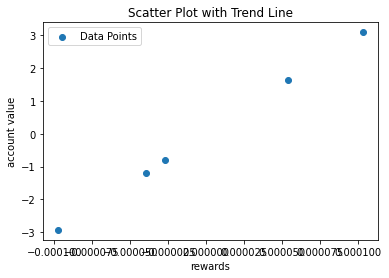

Correlation between 'rewards' and 'account value increase is': 0.9999825599617396


In [6]:
records = pd.DataFrame(columns=["r", "av"])
for i in range(5):
    pv,r = evaluation()
    av_change = ((pv - 1000) / 1000) * 100
    records.loc[len(records)] = [r, av_change]
scatter_plot_with_trend(records)
correlation = records['r'].corr(records['av'])
print("Correlation between 'rewards' and 'account value increase is':", correlation)